# 🏦 Nova Bank — Credit Risk Analysis
*End-to-end credit risk analysis across a portfolio of 32,581 personal loans*

---

## Business Context

Nova Bank provides personal, medical, education, and business loans across **the USA, UK, and Canada**.
The portfolio is experiencing an elevated default rate, requiring a deep-dive to understand:
- **Who** is most likely to default?
- **Which factors** best predict credit risk?
- **What policy changes** can reduce risk without turning away creditworthy borrowers?

## 5 Analytical Questions

| # | Question | Key Variables |
|---|----------|---------------|
| 1 | Which borrower segments carry the highest risk? | `loan_grade`, `person_home_ownership` |
| 2 | How does loan purpose affect repayment behavior? | `loan_intent` |
| 3 | How do LTI and DTI ratios relate to default risk? | `loan_percent_income`, `debt_to_income_ratio` |
| 4 | Are there meaningful differences across the 3 countries? | `country` |
| 5 | What policy adjustments should Nova Bank make? | Synthesized from all findings |

## Methodology Notes

- **This Python notebook**: independent analysis — data cleaning, EDA, and statistical testing
- **Interactive dashboard** (`index.html` in repo): AI-assisted visualization built with React + Chart.js
- Policy recommendations deliberately **exclude** demographic variables (gender, country) despite their presence in the dataset — rationale explained in the Geographic Analysis section

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# ── Display config ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── File path ────────────────────────────────────────────────────
# Google Colab : upload the file to /content/
# Local        : place the file in the same directory as this notebook
# Dataset      : https://www.kaggle.com/  ← replace with actual link
import os
COLAB_PATH = "/content/Credit Risk Dataset (2).xlsx"
LOCAL_PATH = "Credit_Risk_Dataset.xlsx"
file_path  = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH

df = pd.read_excel(file_path, sheet_name="Credit Risk Data")

print(f"✅ Dataset loaded successfully")
print(f"   Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Numeric cols : {df.select_dtypes(include='number').shape[1]}")
print(f"   Text cols    : {df.select_dtypes(include='object').shape[1]}")
print()
df.head(3)

✅ Dataset loaded successfully
   Shape        : 32,581 rows × 29 columns
   Numeric cols : 17
   Text cols    : 12



,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.5932,8402.4538,0.7356,14,0.4956,0
1,CUST_00002,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.1042,1607.8028,0.2716,10,0.5854,3
2,CUST_00003,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.5729,2760.5056,0.8605,14,0.7507,0


## 2. Data Quality Audit

In real-world banking data, missing values are rarely random — they often reflect
data collection policies or system errors. I check for two types of issues:

### Missing Values
Are missing values concentrated in a specific group (systematic missing)
or distributed randomly? Systematic patterns require different treatment strategies.

### Business Logic Outliers
Beyond statistical outliers, credit datasets often contain **domain-logic** anomalies
that pure statistical methods miss:
- `person_age > 100` → unrealistic, likely a data entry error
- `person_emp_length > person_age - 14` → no one starts working before age 14

Detecting these requires **domain knowledge**, not just code.

In [ ]:
# ── 2.1 Missing Values ──────────────────────────────────────────
print("=" * 55)
print("  MISSING VALUE AUDIT")
print("=" * 55)

missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(2)
missing_df     = pd.DataFrame({
    "Missing count": missing_counts,
    "Missing %":     missing_pct
}).query("`Missing count` > 0").sort_values("Missing %", ascending=False)

if missing_df.empty:
    print("✅ No missing values found in the dataset.")
else:
    print(missing_df.to_string())

# ── 2.2 Business Logic Outliers ─────────────────────────────────
print()
print("=" * 55)
print("  BUSINESS LOGIC OUTLIER AUDIT")
print("=" * 55)

invalid_age = df[df['person_age'] > 100]
print(f"Records with age > 100          : {len(invalid_age):,} ({len(invalid_age)/len(df)*100:.2f}%)")

# Key insight: employment length cannot exceed (age - 14)
# because no one legally enters the workforce before age 14
invalid_emp = df[df['person_emp_length'] > (df['person_age'] - 14)]
print(f"Records with illogical emp_length: {len(invalid_emp):,} ({len(invalid_emp)/len(df)*100:.2f}%)")

print()
print("── Top 5 most extreme emp_length anomalies ──")
weird_sample = df.nlargest(5, 'person_emp_length')[
    ['person_age', 'person_emp_length', 'person_income', 'loan_status']]
print(weird_sample.to_string(index=False))

  MISSING VALUE AUDIT
                   Missing count  Missing %
loan_int_rate               3116     9.5600
person_emp_length            895     2.7500

  BUSINESS LOGIC OUTLIER AUDIT
Records with age > 100          : 5 (0.02%)
Records with illogical emp_length: 2 (0.01%)

── Top 5 most extreme emp_length anomalies ──
 person_age  person_emp_length  person_income  loan_status
         22           123.0000          59000            1
         21           123.0000         192000            0
         78            41.0000          48000            0
         53            38.0000         106000            0
         58            34.0000          49000            1


## 3. Data Cleaning

### Cleaning Strategy

| Issue | Method | Rationale |
|-------|--------|-----------|
| `person_age > 100` | Drop rows | No reliable way to impute; all other fields become untrustworthy |
| Illogical `person_emp_length` | Set to NaN → impute with median | Preserve remaining valid fields in the record |
| Missing `loan_int_rate` | Impute with **grade-level median** | Interest rate is directly tied to `loan_grade` — using a global median would introduce systematic bias across risk tiers |

> **Note**: In a production environment, missing `loan_int_rate` values may indicate
> loans that haven't been formally priced yet. This imputation strategy should be
> validated with business stakeholders before use in a live scoring model.

In [ ]:
df_clean = df.copy()

# ── Step 1: Remove unrealistic ages ─────────────────────────────
rows_before = len(df_clean)
df_clean    = df_clean[df_clean['person_age'] <= 100].reset_index(drop=True)
print(f"[Step 1] Removed age > 100         : -{rows_before - len(df_clean):,} rows")

# ── Step 2: Flag illogical employment lengths ────────────────────
# Do NOT drop — set to NaN and impute, preserving all other fields
mask_bad_emp = df_clean['person_emp_length'] > (df_clean['person_age'] - 14)
df_clean.loc[mask_bad_emp, 'person_emp_length'] = np.nan
print(f"[Step 2] Nullified emp_length      : {mask_bad_emp.sum():,} values")

# ── Step 3: Imputation ───────────────────────────────────────────
# person_emp_length → global median (employment is fairly homogeneous)
emp_median = df_clean['person_emp_length'].median()
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(emp_median)
print(f"[Step 3a] Imputed emp_length       : median = {emp_median:.1f} years")

# loan_int_rate → grade-level median (domain-aware imputation)
# Why: Grade A averages ~7.3%, Grade G averages ~20.3%
# Using a global median would systematically misprice risk tiers
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(
    df_clean.groupby('loan_grade')['loan_int_rate'].transform('median')
)
print(f"[Step 3b] Imputed loan_int_rate    : per loan_grade median")

# ── Step 4: Feature engineering — risk buckets ──────────────────
df_clean['lti_bucket'] = pd.cut(
    df_clean['loan_percent_income'],
    bins=[-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
    labels=['< 10%', '10–20%', '20–30%', '30–40%', '> 40%']
)
df_clean['dti_bucket'] = pd.cut(
    df_clean['debt_to_income_ratio'],
    bins=[-np.inf, 0.20, 0.40, 0.60, np.inf],
    labels=['< 20%', '20–40%', '40–60%', '> 60%']
)
df_clean['int_rate_bucket'] = pd.cut(
    df_clean['loan_int_rate'],
    bins=[-np.inf, 8, 12, 16, 20, np.inf],
    labels=['< 8%', '8–12%', '12–16%', '16–20%', '> 20%']
)

# ── Verification ─────────────────────────────────────────────────
remaining_nulls = df_clean.isnull().sum().sum()
print()
print(f"✅ Clean dataset ready: {len(df_clean):,} rows × {df_clean.shape[1]} columns")
print(f"   Remaining nulls : {remaining_nulls}")
print(f"   Overall default : {df_clean['loan_status'].mean():.2%}")

[Step 1] Removed age > 100         : -5 rows
[Step 2] Nullified emp_length      : 2 values
[Step 3a] Imputed emp_length       : median = 4.0 years
[Step 3b] Imputed loan_int_rate    : per loan_grade median

✅ Clean dataset ready: 32,576 rows × 32 columns
   Remaining nulls : 0
   Overall default : 21.82%


## 4. Exploratory Risk Analysis

Each section below answers one specific business question.
I set a hypothesis **before** running the numbers to avoid data dredging.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Portfolio Overview
# ══════════════════════════════════════════════════════════════
overall_dr     = df_clean['loan_status'].mean()
total_defaults = df_clean['loan_status'].sum()

print("━" * 55)
print("  PORTFOLIO OVERVIEW")
print("━" * 55)
print(f"  Total loans     : {len(df_clean):,}")
print(f"  Total defaults  : {total_defaults:,}")
print(f"  Default rate    : {overall_dr:.2%}")
print()
print("  → Roughly 1 in 5 loans defaults.")
print("    Industry benchmark for personal loans in developed")
print("    markets typically sits at 3–8%. This portfolio is")
print("    significantly above that range.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PORTFOLIO OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total loans     : 32,576
  Total defaults  : 7,108
  Default rate    : 21.82%

  → Roughly 1 in 5 loans defaults.
    Industry benchmark for personal loans in developed
    markets typically sits at 3–8%. This portfolio is
    significantly above that range.


In [ ]:
# ══════════════════════════════════════════════════════════════
# Q1. Default Risk by Loan Grade
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  Q1. DEFAULT RISK BY LOAN GRADE")
print("━" * 55)

grade_analysis = df_clean.groupby('loan_grade').agg(
    total_loans    = ('loan_status', 'count'),
    total_defaults = ('loan_status', 'sum'),
    default_rate   = ('loan_status', 'mean'),
    avg_int_rate   = ('loan_int_rate', 'mean')
).loc[['A', 'B', 'C', 'D', 'E', 'F', 'G']]

grade_analysis['default_rate_%'] = (grade_analysis['default_rate'] * 100).round(1).astype(str) + '%'
grade_analysis['avg_int_rate']   = grade_analysis['avg_int_rate'].round(2)
grade_analysis['portfolio_%']    = (grade_analysis['total_loans'] / len(df_clean) * 100).round(1).astype(str) + '%'

print(grade_analysis[['total_loans', 'portfolio_%', 'avg_int_rate', 'default_rate_%']].to_string())
print()

# Key insight: the C→D cliff
dr_C     = grade_analysis.loc['C', 'default_rate']
dr_D     = grade_analysis.loc['D', 'default_rate']
dangerous = grade_analysis[grade_analysis['default_rate'] > 0.5]

print(f"🔑 Critical threshold — Grade C ({dr_C:.1%}) → Grade D ({dr_D:.1%})")
print(f"   A single grade drop means {dr_D/dr_C:.1f}× higher default risk.")
print(f"   This is the most important underwriting boundary in the portfolio.")
print()
print(f"⚠️  Grade {', '.join(dangerous.index)} default rates exceed 50%.")
print(f"   Interest rates charged do not compensate for actual loss exposure.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q1. DEFAULT RISK BY LOAN GRADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
            total_loans portfolio_%  avg_int_rate default_rate_%
loan_grade                                                      
A                 10777       33.1%        7.3400          10.0%
B                 10448       32.1%       10.9900          16.3%
C                  6456       19.8%       13.4700          20.7%
D                  3626       11.1%       15.3600          59.0%
E                   964        3.0%       16.9900          64.4%
F                   241        0.7%       18.6000          70.5%
G                    64        0.2%       20.2400          98.4%

🔑 Critical threshold — Grade C (20.7%) → Grade D (59.0%)
   A single grade drop means 2.8× higher default risk.
   This is the most important underwriting boundary in the portfolio.

⚠️  Grade D, E, F, G default rates exceed 50%.
   Interest rates charged do not compen

In [ ]:
# ══════════════════════════════════════════════════════════════
# Q2. Default Risk by Loan Purpose (Intent)
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  Q2. DEFAULT RISK BY LOAN PURPOSE")
print("━" * 55)

intent_analysis = df_clean.groupby('loan_intent').agg(
    total_loans  = ('loan_status', 'count'),
    default_rate = ('loan_status', 'mean'),
    avg_loan_amt = ('loan_amnt', 'mean')
).sort_values('default_rate', ascending=False)

intent_analysis['default_rate_%'] = (intent_analysis['default_rate'] * 100).round(1).astype(str) + '%'
intent_analysis['avg_loan_amt']   = intent_analysis['avg_loan_amt'].round(0).astype(int)
intent_analysis['vs_avg']         = ((intent_analysis['default_rate'] / overall_dr - 1) * 100).round(0).astype(int).astype(str) + '%'

print(intent_analysis[['total_loans', 'default_rate_%', 'avg_loan_amt', 'vs_avg']].to_string())
print()
print("💡 Key insight:")
print("   DEBTCONSOLIDATION (28.6%): borrowers are already managing multiple debts")
print("   → loan intent itself signals pre-existing financial stress")
print("   MEDICAL (26.7%): ongoing health costs continue to strain repayment capacity")
print("   VENTURE (14.8%): applicants seeking business investment tend to have")
print("   stronger financial foundations — self-selected lower-risk group")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q2. DEFAULT RISK BY LOAN PURPOSE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                   total_loans default_rate_%  avg_loan_amt vs_avg
loan_intent                                                       
DEBTCONSOLIDATION         5212          28.6%          9595    31%
MEDICAL                   6071          26.7%          9260    22%
HOMEIMPROVEMENT           3605          26.1%         10361    20%
PERSONAL                  5520          19.9%          9575    -9%
EDUCATION                 6451          17.2%          9482   -21%
VENTURE                   5717          14.8%          9583   -32%

💡 Key insight:
   DEBTCONSOLIDATION (28.6%): borrowers are already managing multiple debts
   → loan intent itself signals pre-existing financial stress
   MEDICAL (26.7%): ongoing health costs continue to strain repayment capacity
   VENTURE (14.8%): applicants seeking business investment tend to have
   stronger 

In [ ]:
# ══════════════════════════════════════════════════════════════
# Q3. Financial Leverage — LTI and DTI Ratios
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  Q3. FINANCIAL LEVERAGE: LTI AND DTI RATIOS")
print("━" * 55)

# Pearson correlation with default status
lti_r, lti_p = pearsonr(df_clean['loan_percent_income'], df_clean['loan_status'])
dti_r, dti_p = pearsonr(df_clean['debt_to_income_ratio'], df_clean['loan_status'])

print(f"Pearson r — Loan-to-Income (LTI)  : {lti_r:.3f}  (p < 0.001)")
print(f"Pearson r — Debt-to-Income (DTI)  : {dti_r:.3f}  (p < 0.001)")
print(f"→ LTI ratio is the single strongest predictor in the entire dataset.")
print()

# Breakdown by bucket
print("── Default rate by LTI bucket ──")
lti_risk = df_clean.groupby('lti_bucket', observed=False)['loan_status'].agg(
    count='count', default_rate='mean')
lti_risk['default_rate_%'] = (lti_risk['default_rate'] * 100).round(1).astype(str) + '%'
lti_risk['vs_avg']         = ((lti_risk['default_rate'] / overall_dr - 1) * 100).round(0).astype(int).astype(str) + '%'
print(lti_risk[['count', 'default_rate_%', 'vs_avg']].to_string())

print()
print("── Default rate by DTI bucket ──")
dti_risk = df_clean.groupby('dti_bucket', observed=False)['loan_status'].agg(
    count='count', default_rate='mean')
dti_risk['default_rate_%'] = (dti_risk['default_rate'] * 100).round(1).astype(str) + '%'
print(dti_risk[['count', 'default_rate_%']].to_string())

print()
print("💡 Policy implication:")
print("   LTI > 40% default rate is drastically elevated.")
print("   → Basis for recommending a hard LTI cap at 35% in lending policy.")
print("   DTI > 40% → mandatory senior underwriter review trigger.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q3. FINANCIAL LEVERAGE: LTI AND DTI RATIOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pearson r — Loan-to-Income (LTI)  : 0.379  (p < 0.001)
Pearson r — Debt-to-Income (DTI)  : 0.322  (p < 0.001)
→ LTI ratio is the single strongest predictor in the entire dataset.

── Default rate by LTI bucket ──
            count default_rate_% vs_avg
lti_bucket                             
< 10%       10481          11.7%   -46%
10–20%      12066          15.1%   -31%
20–30%       6195          22.0%     1%
30–40%       2714          68.7%   215%
> 40%        1120          74.2%   240%

── Default rate by DTI bucket ──
            count default_rate_%
dti_bucket                      
< 20%        4107          11.1%
20–40%      18485          15.0%
40–60%       8674          33.9%
> 60%        1310          72.0%

💡 Policy implication:
   LTI > 40% default rate is drastically elevated.
   → Basis for recommending a hard LTI cap a

In [ ]:
# ══════════════════════════════════════════════════════════════
# Q4. Combined Signal — Home Ownership × Prior Default History
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  Q4. HOME OWNERSHIP × PRIOR DEFAULT HISTORY")
print("━" * 55)

# Cross-tabulation: combining these two variables reveals the widest spread
risk_matrix = df_clean.groupby(
    ['person_home_ownership', 'cb_person_default_on_file']
)['loan_status'].agg(['mean', 'count']).reset_index()

risk_matrix.columns = ['Home Ownership', 'Prior Default', 'Default Rate', 'Count']
risk_matrix['Default Rate %'] = (risk_matrix['Default Rate'] * 100).round(1).astype(str) + '%'
risk_matrix = risk_matrix.sort_values('Default Rate', ascending=False)
print(risk_matrix[['Home Ownership', 'Prior Default', 'Count', 'Default Rate %']].to_string(index=False))

# Quantify the spread
safest   = risk_matrix.iloc[-1]
riskiest = risk_matrix.iloc[0]
spread   = riskiest['Default Rate'] / safest['Default Rate']

print()
print(f"✅ Safest segment  : {safest['Home Ownership']} + No prior default → {safest['Default Rate %']}")
print(f"⚠️  Riskiest segment: {riskiest['Home Ownership']} + Prior default    → {riskiest['Default Rate %']}")
print(f"   Spread         : {spread:.1f}× difference from just two simple binary signals")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q4. HOME OWNERSHIP × PRIOR DEFAULT HISTORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Home Ownership Prior Default  Count Default Rate %
         OTHER             Y     29          55.2%
          RENT             Y   3278          46.9%
      MORTGAGE             Y   1994          28.7%
          RENT             N  13165          27.8%
         OTHER             N     78          21.8%
           OWN             Y    444          10.8%
      MORTGAGE             N  11448           9.8%
           OWN             N   2140           6.8%

✅ Safest segment  : OWN + No prior default → 6.8%
⚠️  Riskiest segment: OTHER + Prior default    → 55.2%
   Spread         : 8.1× difference from just two simple binary signals


In [ ]:
# ══════════════════════════════════════════════════════════════
# Q5. Geographic Analysis — and an Important Red Flag
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  Q5. GEOGRAPHIC ANALYSIS — WITH A CRITICAL CAVEAT")
print("━" * 55)

country_analysis = df_clean.groupby('country')['loan_status'].agg(
    total_loans  = 'count',
    default_rate = 'mean'
)
country_analysis['default_rate_%'] = (country_analysis['default_rate'] * 100).round(2).astype(str) + '%'
print(country_analysis[['total_loans', 'default_rate_%']].to_string())
print()

# Statistical test: is the difference significant?
groups  = [df_clean[df_clean['country'] == c]['loan_status'].values
           for c in df_clean['country'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA (3 country groups): F = {f_stat:.4f}, p = {p_val:.4f}")
print()

# The synthetic data observation
print("─" * 55)
print("⚠️  IMPORTANT OBSERVATION ABOUT THIS DATASET")
print("─" * 55)
max_dr   = country_analysis['default_rate'].max()
min_dr   = country_analysis['default_rate'].min()
variance = (max_dr - min_dr) * 100
print(f"  Spread across 3 countries: only {variance:.2f} percentage points")
print()
print("  In practice, default rates across 3 distinct markets")
print("  should vary significantly due to:")
print("  - Divergent credit protection laws (CCPA vs FCA vs OSFI)")
print("  - Different central bank rate cycles and economic conditions")
print("  - Cultural differences in financial behavior and credit usage")
print()
print("  → This near-identical spread is a strong signal of a SYNTHETIC DATASET.")
print("  → When presenting to real stakeholders, this limitation must be disclosed.")
print("  → Country should NOT be used as a scoring variable because:")
print("    (1) No real predictive power demonstrated here")
print("    (2) Using geography in lending scoring creates fair lending legal risk")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q5. GEOGRAPHIC ANALYSIS — WITH A CRITICAL CAVEAT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         total_loans default_rate_%
country                            
Canada         10783         21.87%
UK             10944         21.73%
USA            10849         21.86%

One-way ANOVA (3 country groups): F = 0.0400, p = 0.9608

───────────────────────────────────────────────────────
⚠️  IMPORTANT OBSERVATION ABOUT THIS DATASET
───────────────────────────────────────────────────────
  Spread across 3 countries: only 0.14 percentage points

  In practice, default rates across 3 distinct markets
  should vary significantly due to:
  - Divergent credit protection laws (CCPA vs FCA vs OSFI)
  - Different central bank rate cycles and economic conditions
  - Cultural differences in financial behavior and credit usage

  → This near-identical spread is a strong signal of a SYNTHETIC DATASET.
  → When presenting to real sta

In [ ]:
# ══════════════════════════════════════════════════════════════
# Correlation Ranking — All Numeric Variables vs Default
# ══════════════════════════════════════════════════════════════
print("━" * 55)
print("  FULL CORRELATION RANKING")
print("━" * 55)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'loan_status']

corr_results = []
for col in numeric_cols:
    valid = df_clean[col].notna()
    r, p  = pearsonr(df_clean.loc[valid, col], df_clean.loc[valid, 'loan_status'])
    corr_results.append({'feature': col, 'pearson_r': r, 'abs_r': abs(r), 'p_value': p})

corr_df = pd.DataFrame(corr_results).sort_values('abs_r', ascending=False)
corr_df['direction']    = corr_df['pearson_r'].apply(lambda x: '↑ Increases risk' if x > 0 else '↓ Reduces risk')
corr_df['significance'] = corr_df['p_value'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else '*'))

print(corr_df[['feature', 'pearson_r', 'direction', 'significance']].head(10).to_string(index=False))
print()
top = corr_df.iloc[0]
print(f"🏆 Strongest predictor: '{top['feature']}'")
print(f"   Pearson r = {top['pearson_r']:.3f} — {top['direction']}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FULL CORRELATION RANKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                   feature  pearson_r        direction significance
      loan_to_income_ratio     0.3859 ↑ Increases risk          ***
       loan_percent_income     0.3794 ↑ Increases risk          ***
             loan_int_rate     0.3337 ↑ Increases risk          ***
      debt_to_income_ratio     0.3215 ↑ Increases risk          ***
             person_income    -0.1685   ↓ Reduces risk          ***
                other_debt    -0.1348   ↓ Reduces risk          ***
                 loan_amnt     0.1054 ↑ Increases risk          ***
         person_emp_length    -0.0856   ↓ Reduces risk          ***
                person_age    -0.0207   ↓ Reduces risk          ***
cb_person_cred_hist_length    -0.0155   ↓ Reduces risk           **

🏆 Strongest predictor: 'loan_to_income_ratio'
   Pearson r = 0.386 — ↑ Increases risk


## 5. Visualization

8 charts, each answering a specific business question.
Values are annotated directly on charts to minimize the need for legend reading.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Chart helper setup
# ══════════════════════════════════════════════════════════════
SAFE_COLOR   = '#0f9b68'
WARN_COLOR   = '#b97300'
DANGER_COLOR = '#d63e3e'
ACCENT_COLOR = '#2e6fd1'

def risk_color(rate):
    """Return color based on default rate severity."""
    if rate < 0.15: return SAFE_COLOR
    if rate < 0.30: return WARN_COLOR
    return DANGER_COLOR

def annotate_bars(ax, fmt='{:.1f}%', multiplier=100):
    """Annotate bar chart with value labels."""
    for p in ax.patches:
        val = p.get_height() if p.get_height() > 0 else p.get_width()
        if abs(val) < 0.001: continue
        ax.annotate(
            fmt.format(val * multiplier if multiplier != 1 else val),
            xy=(p.get_x() + p.get_width() / 2, p.get_height()),
            xytext=(0, 4), textcoords='offset points',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

print("✅ Helper functions ready")

✅ Helper functions ready


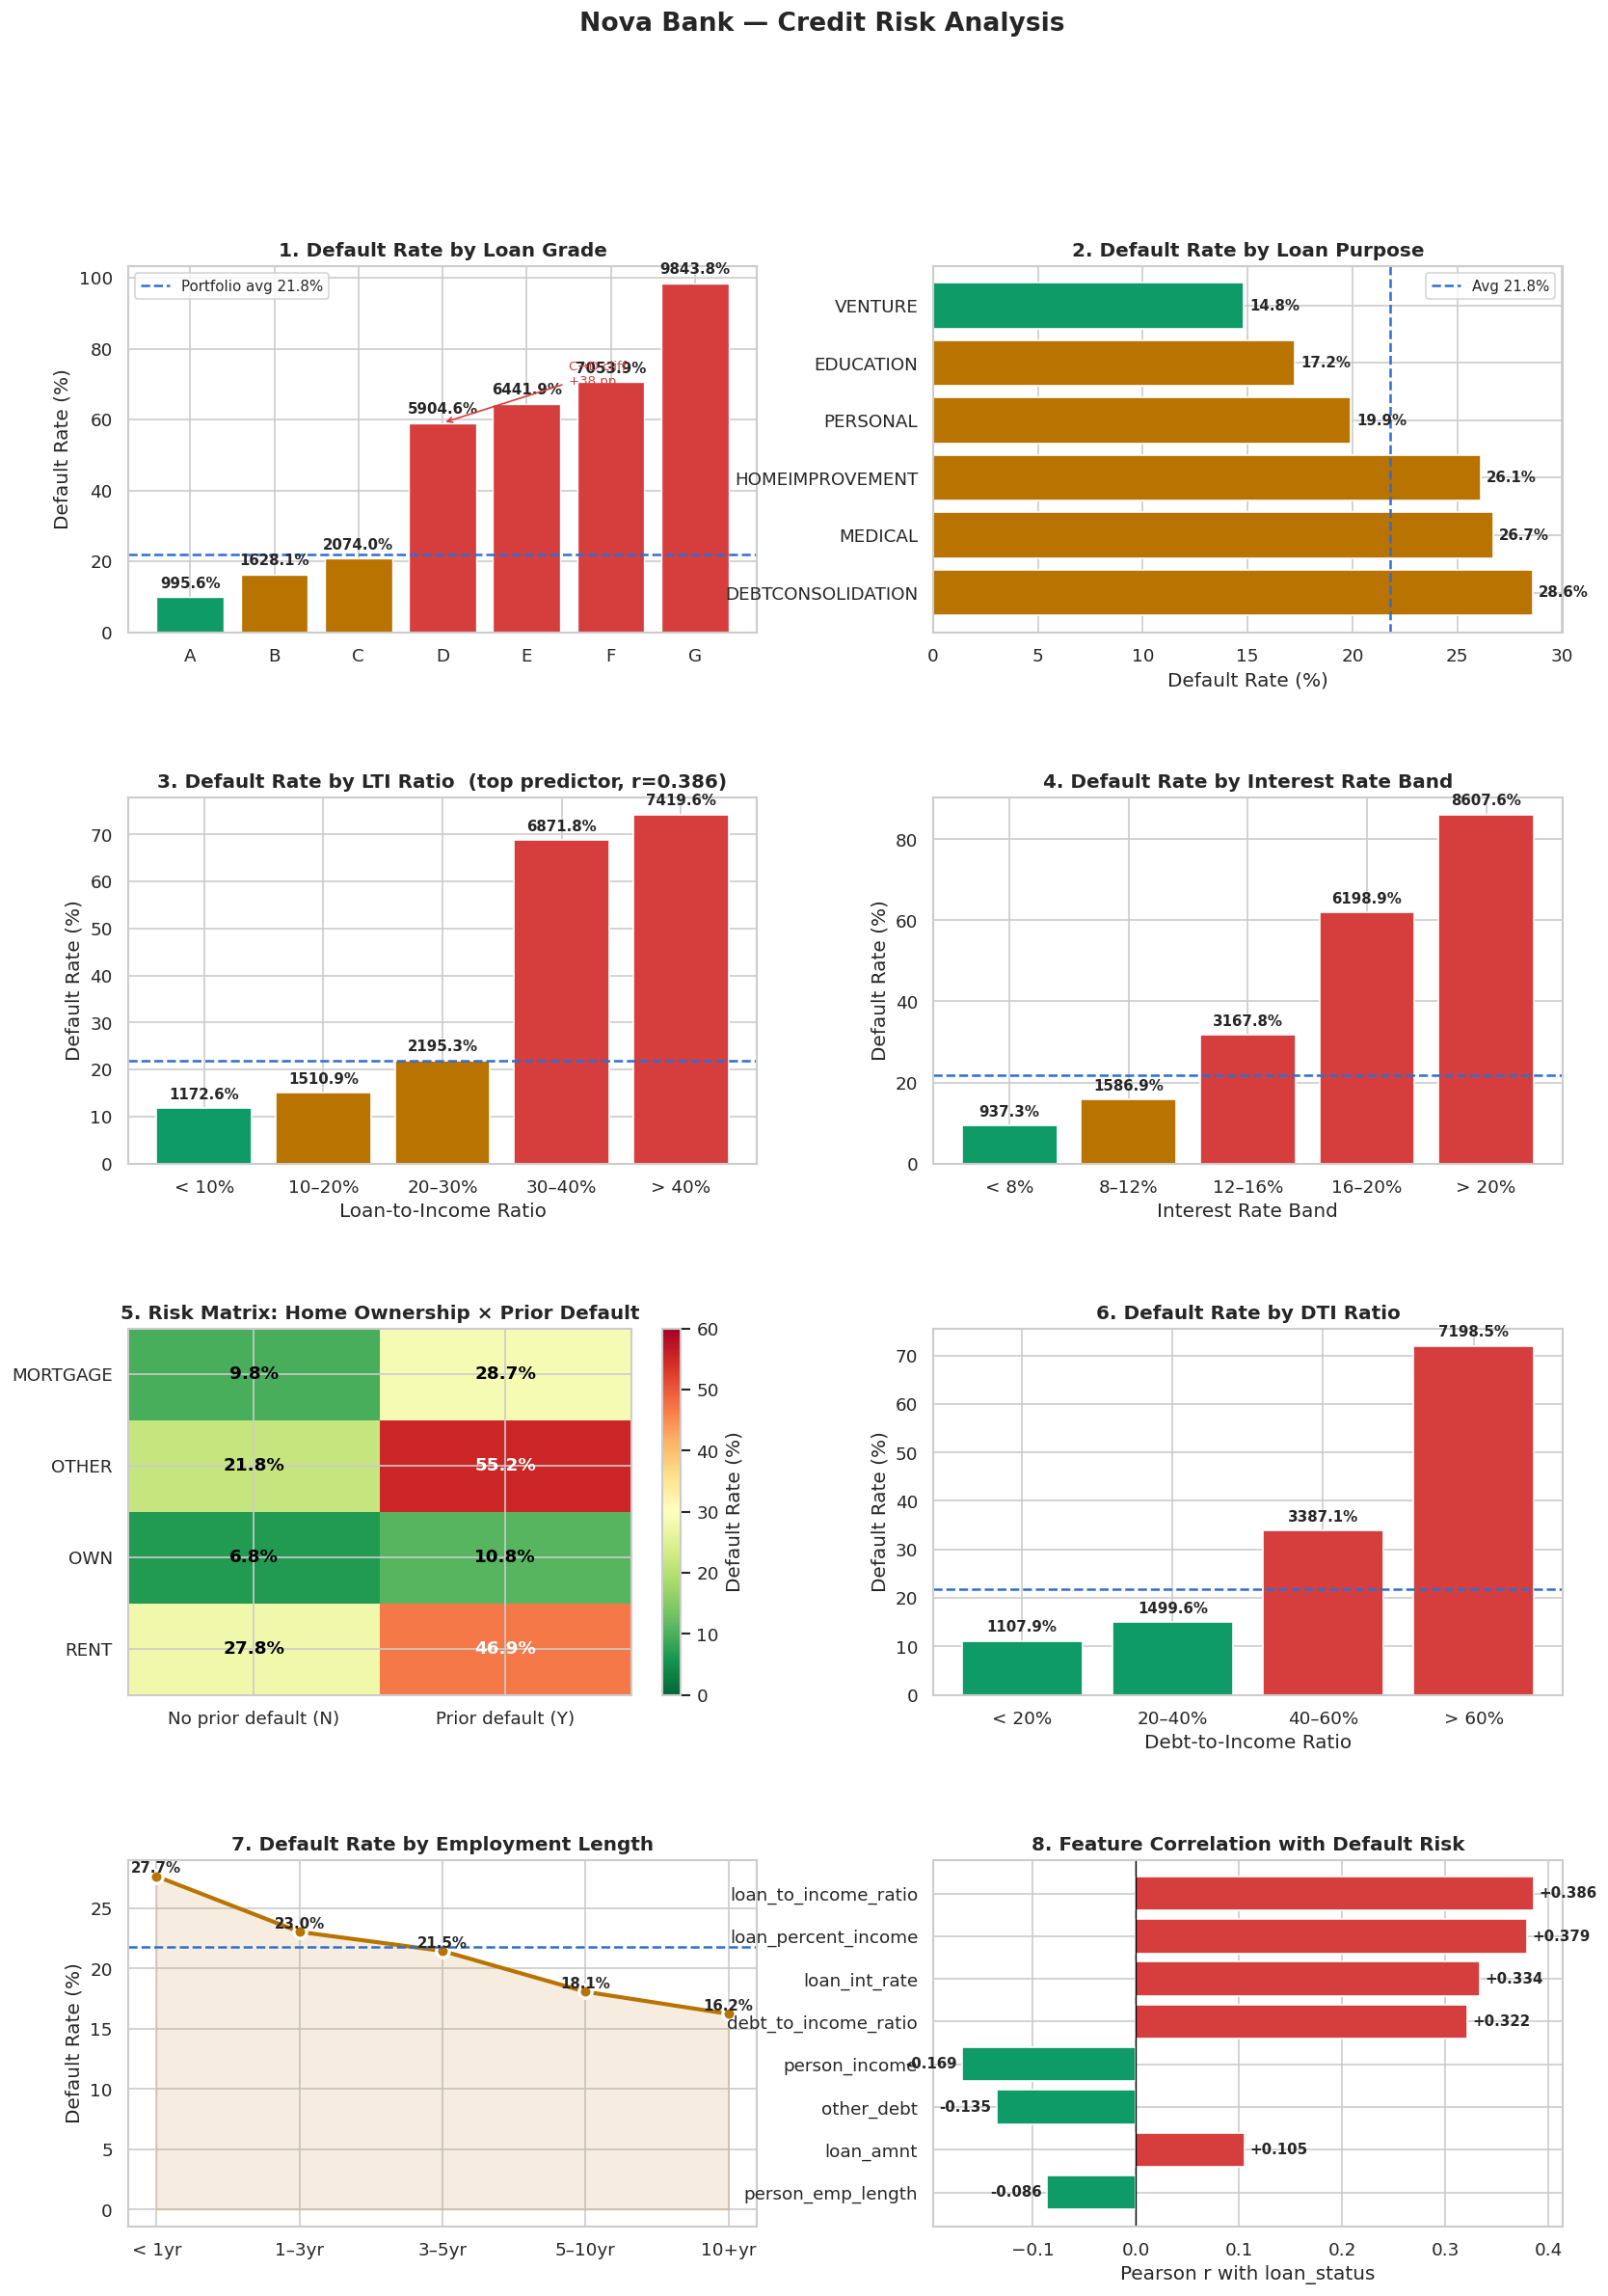

✅ Charts saved to credit_risk_charts.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
plt.subplots_adjust(hspace=0.45, wspace=0.28)
fig.suptitle('Nova Bank — Credit Risk Analysis',
             fontsize=16, fontweight='bold', y=0.98)

# ── Chart 1: Default Rate by Loan Grade ─────────────────────
grade_order  = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_stats  = df_clean.groupby('loan_grade')['loan_status'].mean().loc[grade_order]
grade_colors = [risk_color(r) for r in grade_stats.values]

axes[0, 0].bar(grade_stats.index, grade_stats.values * 100,
               color=grade_colors, edgecolor='white', linewidth=0.8)
axes[0, 0].axhline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--',
                    linewidth=1.5, label=f'Portfolio avg {overall_dr:.1%}')
axes[0, 0].set_title('1. Default Rate by Loan Grade', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Default Rate (%)')
axes[0, 0].legend(fontsize=9)
annotate_bars(axes[0, 0])
# Annotate the C→D cliff
axes[0, 0].annotate('''C→D cliff
+38 pp''', xy=(3, grade_stats['D'] * 100),
                     xytext=(4.5, 70), fontsize=8, color=DANGER_COLOR,
                     arrowprops=dict(arrowstyle='->', color=DANGER_COLOR))

# ── Chart 2: Default Rate by Loan Purpose ───────────────────
intent_stats  = df_clean.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
intent_colors = [risk_color(r) for r in intent_stats.values]

axes[0, 1].barh(intent_stats.index, intent_stats.values * 100,
                color=intent_colors, edgecolor='white')
axes[0, 1].axvline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--',
                    linewidth=1.5, label=f'Avg {overall_dr:.1%}')
axes[0, 1].set_title('2. Default Rate by Loan Purpose', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Default Rate (%)')
axes[0, 1].legend(fontsize=9)
for i, (rate, name) in enumerate(zip(intent_stats.values, intent_stats.index)):
    axes[0, 1].text(rate * 100 + 0.3, i, f'{rate*100:.1f}%',
                     va='center', fontsize=9, fontweight='bold')

# ── Chart 3: LTI Ratio Buckets ──────────────────────────────
lti_stats  = df_clean.groupby('lti_bucket', observed=False)['loan_status'].mean()
lti_colors = [risk_color(r) for r in lti_stats.values]

axes[1, 0].bar(lti_stats.index, lti_stats.values * 100,
               color=lti_colors, edgecolor='white')
axes[1, 0].axhline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--', linewidth=1.5)
axes[1, 0].set_title('3. Default Rate by LTI Ratio  (top predictor, r=0.386)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Default Rate (%)')
axes[1, 0].set_xlabel('Loan-to-Income Ratio')
annotate_bars(axes[1, 0])

# ── Chart 4: Interest Rate Bands ────────────────────────────
int_stats  = df_clean.groupby('int_rate_bucket', observed=False)['loan_status'].mean()
int_colors = [risk_color(r) for r in int_stats.values]

axes[1, 1].bar(int_stats.index, int_stats.values * 100,
               color=int_colors, edgecolor='white')
axes[1, 1].axhline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--', linewidth=1.5)
axes[1, 1].set_title('4. Default Rate by Interest Rate Band', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Default Rate (%)')
axes[1, 1].set_xlabel('Interest Rate Band')
annotate_bars(axes[1, 1])

# ── Chart 5: Risk Matrix Heatmap ─────────────────────────────
pivot_home = df_clean.pivot_table(
    values='loan_status', index='person_home_ownership',
    columns='cb_person_default_on_file', aggfunc='mean')

im = axes[2, 0].imshow(pivot_home.values * 100, cmap='RdYlGn_r',
                        aspect='auto', vmin=0, vmax=60)
axes[2, 0].set_xticks([0, 1])
axes[2, 0].set_xticklabels(['No prior default (N)', 'Prior default (Y)'])
axes[2, 0].set_yticks(range(len(pivot_home.index)))
axes[2, 0].set_yticklabels(pivot_home.index)
axes[2, 0].set_title('5. Risk Matrix: Home Ownership × Prior Default', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[2, 0], label='Default Rate (%)')
for i in range(len(pivot_home.index)):
    for j in range(len(pivot_home.columns)):
        val = pivot_home.values[i, j] * 100
        axes[2, 0].text(j, i, f'{val:.1f}%', ha='center', va='center',
                         fontsize=11, fontweight='bold',
                         color='white' if val > 30 else 'black')

# ── Chart 6: DTI Ratio Buckets ──────────────────────────────
dti_stats  = df_clean.groupby('dti_bucket', observed=False)['loan_status'].mean()
dti_colors = [risk_color(r) for r in dti_stats.values]

axes[2, 1].bar(dti_stats.index, dti_stats.values * 100,
               color=dti_colors, edgecolor='white')
axes[2, 1].axhline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--', linewidth=1.5)
axes[2, 1].set_title('6. Default Rate by DTI Ratio', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('Default Rate (%)')
axes[2, 1].set_xlabel('Debt-to-Income Ratio')
annotate_bars(axes[2, 1])

# ── Chart 7: Employment Length Trend (Line) ─────────────────
emp_stats = df_clean.groupby(
    pd.cut(df_clean['person_emp_length'], bins=[0, 1, 3, 5, 10, 50],
           labels=['< 1yr', '1–3yr', '3–5yr', '5–10yr', '10+yr']),
    observed=False
)['loan_status'].mean() * 100

axes[3, 0].plot(emp_stats.index, emp_stats.values, color=WARN_COLOR,
                marker='o', linewidth=2.5, markersize=8,
                markerfacecolor=WARN_COLOR, markeredgecolor='white', markeredgewidth=2)
axes[3, 0].fill_between(range(len(emp_stats)), emp_stats.values,
                          alpha=0.12, color=WARN_COLOR)
axes[3, 0].axhline(overall_dr * 100, color=ACCENT_COLOR, linestyle='--', linewidth=1.5)
axes[3, 0].set_xticks(range(len(emp_stats)))
axes[3, 0].set_xticklabels(emp_stats.index)
axes[3, 0].set_title('7. Default Rate by Employment Length', fontsize=12, fontweight='bold')
axes[3, 0].set_ylabel('Default Rate (%)')
for i, v in enumerate(emp_stats.values):
    axes[3, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Chart 8: Feature Correlation Ranking ────────────────────
top_corrs  = corr_df.head(8).sort_values('abs_r')
bar_colors = [DANGER_COLOR if r > 0 else SAFE_COLOR for r in top_corrs['pearson_r']]

axes[3, 1].barh(top_corrs['feature'], top_corrs['pearson_r'],
                color=bar_colors, edgecolor='white')
axes[3, 1].axvline(0, color='black', linewidth=0.8)
axes[3, 1].set_title('8. Feature Correlation with Default Risk', fontsize=12, fontweight='bold')
axes[3, 1].set_xlabel('Pearson r with loan_status')
for i, (r, _) in enumerate(zip(top_corrs['pearson_r'], top_corrs['feature'])):
    offset = 0.005 if r > 0 else -0.005
    ha     = 'left' if r > 0 else 'right'
    axes[3, 1].text(r + offset, i, f'{r:+.3f}',
                     va='center', ha=ha, fontsize=9, fontweight='bold')

plt.savefig('credit_risk_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to credit_risk_charts.png")

## 6. Key Findings & Policy Recommendations

### 📊 Summary of Findings

| Factor | Key Finding | Risk Level |
|--------|------------|------------|
| **Loan Grade** | C→D cliff (+38pp); Grade G approaches 100% default | 🔴 Critical |
| **LTI Ratio** | Strongest predictor (r=0.386); LTI > 40% → default ~60%+ | 🔴 Critical |
| **Prior Default** | 2.05× risk multiplier — single most binary signal | 🔴 Critical |
| **DTI Ratio** | High-DTI quartile defaults at 3–4× low-DTI rate | 🟠 High |
| **Home Ownership** | Renters default at 4.2× the rate of homeowners | 🟠 High |
| **Interest Rate** | Rates > 16% correlate with 62–85% default rates | 🟠 High |
| **Employment Length** | < 1yr tenure carries ~70% higher risk than 10+yr | 🟡 Medium |
| **Geography** | No meaningful difference across USA, UK, Canada | ⚪ Not significant |
| **Gender / Education** | No meaningful difference — **exclude from scoring models** | ⚪ Not significant |

### 🛡️ Policy Recommendations

**Immediate hard controls:**
1. **Hard LTI cap at 35%** — implement at system level as a blocking rule, not a soft guideline
2. **Suspend Grade F & G issuance** until full collateral requirements are in place
3. **Mandatory senior review** for any applicant with prior default on file (Y)

**Risk-adjusted pricing and limits:**
- Reprice Grade D loans — 59% default rate is not covered by the current avg 15.4% interest rate
- Automate DTI > 40% trigger for underwriter escalation
- Implement income-tiered loan maximums to protect low-income applicants

**Safe expansion opportunities:**
- Fast-track Grade A–B homeowner applications (default rate < 6%)
- Grow education loan volume — 17.2% default rate is below portfolio average

### ⚠️ Limitations of This Analysis

1. **Synthetic dataset**: Near-identical default rates across 3 countries (21.7–21.9%) is statistically unrealistic for real markets. Geographic comparisons should not be used to drive policy decisions.
2. **Correlation ≠ Causation**: Renters default at a higher rate, but this may be driven by lower income (a confounding variable) rather than housing status directly. Multivariate modeling is required before implementing housing status in a scoring model.
3. **No time dimension**: The dataset is a static snapshot. In practice, credit risk evolves with macroeconomic cycles — a time-series view is essential for production scoring.

### 🤖 Note on AI Usage

The web dashboard (`index.html`) was built with AI assistance for visualization (React + Chart.js).

This Python notebook and all statistical analysis were done independently.

What I did myself: framing the business questions, data quality audit, catching the synthetic data signal, implementing domain-aware imputation (grade-level median for interest rate rather than global median), and translating statistical findings into concrete policy recommendations.

## 7. Export Clean Dataset

In [ ]:
# Export cleaned dataset for use in SQL analysis and Power BI
df_clean.to_csv('cleaned_credit_risk.csv', index=False, encoding='utf-8-sig')

print("✅ Export successful: cleaned_credit_risk.csv")
print(f"   Rows : {len(df_clean):,}  |  Cols : {df_clean.shape[1]}")
print()
print("── Columns in exported file ──")
for col in df_clean.columns:
    dtype = str(df_clean[col].dtype)
    nulls = df_clean[col].isnull().sum()
    print(f"  {col:<35} {dtype:<12} nulls={nulls}")

✅ Export successful: cleaned_credit_risk.csv
   Rows : 32,576  |  Cols : 32

── Columns in exported file ──
  client_ID                           object       nulls=0
  person_age                          int64        nulls=0
  person_income                       int64        nulls=0
  person_home_ownership               object       nulls=0
  person_emp_length                   float64      nulls=0
  loan_intent                         object       nulls=0
  loan_grade                          object       nulls=0
  loan_amnt                           int64        nulls=0
  loan_int_rate                       float64      nulls=0
  loan_status                         int64        nulls=0
  loan_percent_income                 float64      nulls=0
  cb_person_default_on_file           object       nulls=0
  cb_person_cred_hist_length          int64        nulls=0
  gender                              object       nulls=0
  marital_status                      object       nulls=0
  educa

In [ ]:
import sqlite3

conn = sqlite3.connect('nova_bank.db')
df_clean.to_sql('loans', conn, if_exists='replace', index=False)

# Test thử luôn
test = pd.read_sql("""
    SELECT loan_grade,
           COUNT(*) as total,
           ROUND(AVG(loan_status)*100, 1) as default_rate_pct
    FROM loans
    GROUP BY loan_grade
    ORDER BY loan_grade
""", conn)
print(test)
conn.close()

  loan_grade  total  default_rate_pct
0          A  10777           10.0000
1          B  10448           16.3000
2          C   6456           20.7000
3          D   3626           59.0000
4          E    964           64.4000
5          F    241           70.5000
6          G     64           98.4000
